In [1]:
# 1. Import Libraries
# -------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Set style for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# 2. Load the Dataset
# -------------------
# We'll load the dataset provided: Mall_Customers.csv
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("\nDataset loaded successfully.")
except FileNotFoundError:
    print("\nError: 'Mall_Customers.csv' not found. Please ensure the file is in the same directory.")
    # Create dummy data for demonstration if file is missing (Fallout prevention)
    data = {
        'CustomerID': range(1, 21),
        'Gender': ['Male', 'Male', 'Female', 'Female'] * 5,
        'Age': np.random.randint(18, 70, 20),
        'Annual Income (k$)': np.random.randint(15, 100, 20),
        'Spending Score (1-100)': np.random.randint(1, 100, 20)
    }
    df = pd.DataFrame(data)


Dataset loaded successfully.



--- First 5 rows of the dataset ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ 

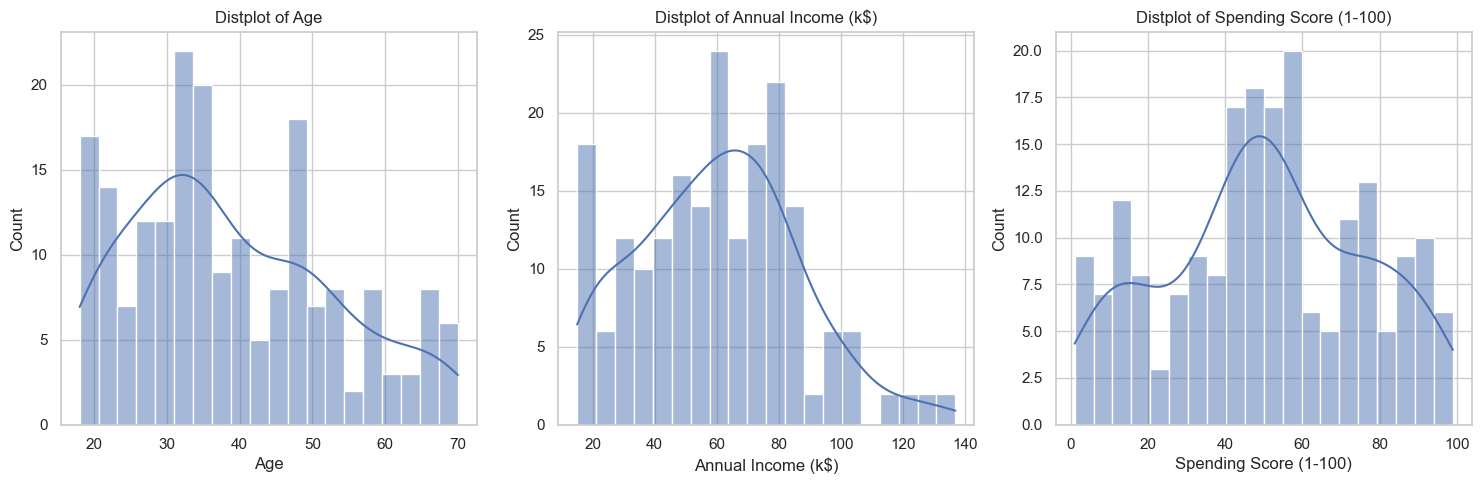

In [3]:
# 3. Exploratory Data Analysis (EDA)
# ----------------------------------
print("\n--- First 5 rows of the dataset ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Descriptive Statistics ---")
print(df.describe())

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Visualizing Distributions of Age, Income, and Spending Score
plt.figure(1, figsize=(15, 5))
n = 0
for x in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1, 3, n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.histplot(df[x], kde=True, bins=20)
    plt.title(f'Distplot of {x}')
plt.tight_layout()
plt.show()

In [4]:
# 4. Feature Selection
# --------------------
# For this analysis, we will cluster customers based on 'Annual Income' and 'Spending Score'.
# This allows us to visualize the clusters easily in a 2D plane.
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

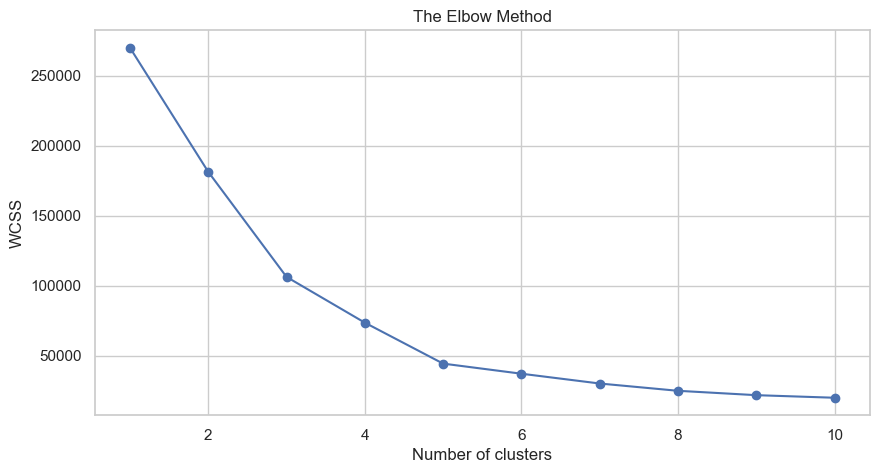


Observation: Look at the Elbow Graph. The curve typically bends around k=5.
We will proceed with 5 clusters.


In [5]:
# 5. Finding Optimal Clusters (The Elbow Method)
# ----------------------------------------------
# We calculate the Within-Cluster Sum of Square (WCSS) for different values of k (1 to 10).
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(2, figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

print("\nObservation: Look at the Elbow Graph. The curve typically bends around k=5.")
print("We will proceed with 5 clusters.")

In [6]:
# 6. Training the K-Means Model
# -----------------------------
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# Add the cluster labels to the original dataframe for analysis
df['Cluster'] = y_kmeans

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


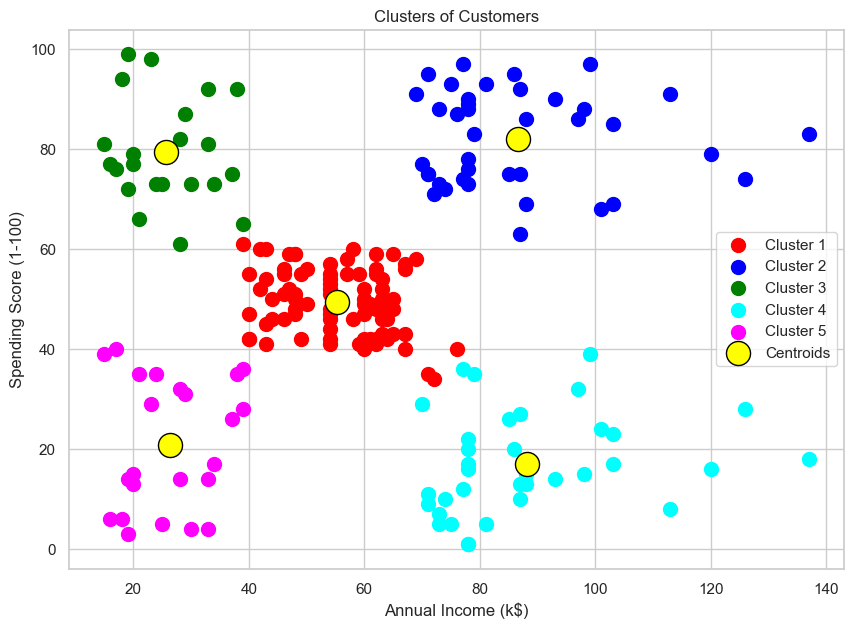

In [7]:
# 7. Visualizing the Clusters
# ---------------------------
plt.figure(3, figsize=(10, 7))

# Plot each cluster
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

for i in range(optimal_k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], 
                s=100, c=colors[i], label=labels[i])

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='yellow', label='Centroids', edgecolors='black')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [8]:
# 8. Cluster Interpretation
# -------------------------
print("\n--- Cluster Interpretation ---")
print("Based on the plot, we can usually identify segments such as:")
print("1. Low Income, Low Spending (Sensible)")
print("2. Low Income, High Spending (Careless)")
print("3. High Income, Low Spending (Miser)")
print("4. High Income, High Spending (Target/VIP)")
print("5. Average Income, Average Spending (Standard)")

print("\n--- Sample of Data with Clusters ---")
display(df.head())


--- Cluster Interpretation ---
Based on the plot, we can usually identify segments such as:
1. Low Income, Low Spending (Sensible)
2. Low Income, High Spending (Careless)
3. High Income, Low Spending (Miser)
4. High Income, High Spending (Target/VIP)
5. Average Income, Average Spending (Standard)

--- Sample of Data with Clusters ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
